# BridgeData Downloader

In [ ]:
from datasets import load_dataset
from huggingface_hub import snapshot_download

def download_bridgedata_datasets():
    ds = {}

    print("Downloading video dataset...")
    ds["video"] = load_dataset("VyoJ/BridgeData-V2-Scripted-Videos")
    print("Finished downloading video dataset.")

    print("Downloading image dataset repo...")
    local_dir = snapshot_download(
        repo_id="VyoJ/BridgeData-V2-Scripted-Images",
        repo_type="dataset",
    )
    print("Loading image dataset as imagefolder...")
    ds["image"] = load_dataset("imagefolder", data_dir=local_dir)
    print("Finished downloading image dataset.")

    return ds


ds = download_bridgedata_datasets()
print(ds)
print("All datasets downloaded successfully.")

# BridgeData Sample Inspection
Inspect one sample from each split: video frames, fps, resolution, and labels.

In [1]:
from datasets import load_dataset

N = 3  # samples to inspect (streams lazily — no full download)

ds = {
    "video": load_dataset("VyoJ/BridgeData-V2-Scripted-Videos", streaming=True),
    "image": load_dataset("VyoJ/BridgeData-V2-Scripted-Images", streaming=True),
}
print(ds)

/home2/reza/.conda/envs/llm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'video': IterableDatasetDict({
    train: IterableDataset({
        features: ['video', 'campaign_name', 'session_name', 'trajectory_name', 'trajectory_index', 'num_frames', 'observation_data', 'policy_data'],
        num_shards: 1
    })
}), 'image': IterableDatasetDict({
    train: IterableDataset({
        features: ['first_image', 'intermediate_image', 'frame_43_image', 'campaign_name', 'session_name', 'trajectory_name', 'trajectory_index', 'trajectory_id'],
        num_shards: 1
    })
})}


## Video dataset

In [2]:
import datasets.config
import datasets  # ensure config is initialised

# torchcodec is installed but broken (missing FFmpeg .so files).
# Disable it before touching any Video column so datasets falls back to
# its plain bytes path instead of trying to import torchcodec.
datasets.config.TORCHCODEC_AVAILABLE = False

from datasets import Video
video_ds = ds['video']['train'].cast_column('video', Video(decode=False))
samples = list(video_ds.take(N))
print('columns     :', video_ds.column_names)
print('features    :')
for k, v in video_ds.features.items():
    print(f'  {k}: {v}')

columns     : ['video', 'campaign_name', 'session_name', 'trajectory_name', 'trajectory_index', 'num_frames', 'observation_data', 'policy_data']
features    :
  video: Video(decode=False, stream_index=None, dimension_order='NCHW', num_ffmpeg_threads=1, device='cpu', seek_mode='exact')
  campaign_name: Value('string')
  session_name: Value('string')
  trajectory_name: Value('string')
  trajectory_index: Value('int64')
  num_frames: Value('int64')
  observation_data: {'joint_effort': List(List(Value('float64'))), 'qpos': List(List(Value('float64'))), 'qvel': List(List(Value('float64'))), 'full_state': List(List(Value('float64'))), 'state': List(List(Value('float64'))), 'desired_state': List(List(Value('float64'))), 'time_stamp': List(Value('float64')), 'eef_transform': List(List(List(Value('float64')))), 'high_bound': List(List(Value('float64'))), 'low_bound': List(List(Value('float64'))), 'env_done': List(Value('bool')), 't_get_obs': List(Value('float64'))}
  policy_data: List({'actions

| Column            | Description                                                                 |
|------------------|-----------------------------------------------------------------------------|
| video            | Raw MP4 video of the robot trajectory                                       |
| campaign_name    | Top-level data collection campaign (e.g. a research phase or operator group)|
| session_name     | Recording session within the campaign (a single day/sitting)               |
| trajectory_name  | Unique identifier for this specific robot trajectory                        |
| trajectory_index | Integer index of the trajectory within its session                          |
| num_frames       | Number of video frames in the trajectory                                    |
| observation_data | Sensory observations at each timestep — typically robot joint positions, end-effector pose, gripper state |
| policy_data      | Actions taken at each timestep — typically the commanded joint velocities or delta end-effector poses |


campaign → session → trajectory form a 3-level hierarchy. 
observation_data and policy_data are likely dicts of arrays with one entry per timestep, matching num_frames.

| Field         | Shape     | Description                                                                 |
|--------------|----------|-----------------------------------------------------------------------------|
| qpos         | [T, D]   | Joint positions                                                             |
| qvel         | [T, D]   | Joint velocities                                                            |
| joint_effort | [T, D]   | Joint torques                                                               |
| state        | [T, D]   | Compact robot state (subset used by policy)                                 |
| full_state   | [T, D]   | Full robot state (all joints/sensors)                                       |
| desired_state| [T, D]   | Target state commanded to the robot                                         |
| eef_transform| [T, 4, 4]| End-effector pose as a 4×4 homogeneous transform matrix                     |
| high_bound   | [T, D]   | Action space upper bounds                                                   |
| low_bound    | [T, D]   | Action space lower bounds                                                   |
| env_done     | [T]      | Whether the episode ended at each timestep                                  |
| time_stamp   | [T]      | Wall-clock time of each observation                                         |
| t_get_obs    | [T]      | Time taken to read the observation (latency profiling)                      |


T = number of timesteps, D = DOF of the robot arm.

In [3]:
sample = samples[0]
print('sample keys:', list(sample.keys()))

sample keys: ['video', 'campaign_name', 'session_name', 'trajectory_name', 'trajectory_index', 'num_frames', 'observation_data', 'policy_data']


In [4]:
# Metadata / labels
for key in ('campaign_name', 'session_name', 'trajectory_name',
            'trajectory_index', 'num_frames'):
    if key in sample:
        print(f'{key}: {sample[key]}')

campaign_name: pnp_utensils_11-29
session_name: 2022-11-29_15-24-23
trajectory_name: traj0
trajectory_index: 0
num_frames: 50


In [7]:
# --- video frames, fps, resolution ---
import numpy as np
from io import BytesIO

video = sample['video']
if video.get('bytes'):
    raw = video['bytes']
else:
    import fsspec
    with fsspec.open(video['path'], 'rb') as f:
        raw = f.read()

try:
    import decord
    vr = decord.VideoReader(BytesIO(raw))
    h, w, c = vr[0].shape
    fps = vr.get_avg_fps()
    n_frames = len(vr)
    print(f'frames      : {n_frames}')
    print(f'fps         : {fps:.2f}')
    print(f'resolution  : {w}x{h}  (WxH), channels={c}')
    print(f'duration    : {n_frames / fps:.2f}s')
except ImportError:
    print('decord not installed — pip install decord')
    print(f'raw video size: {len(raw):,} bytes')

frames      : 50
fps         : 1.00
resolution  : 640x480  (WxH), channels=3
duration    : 50.00s


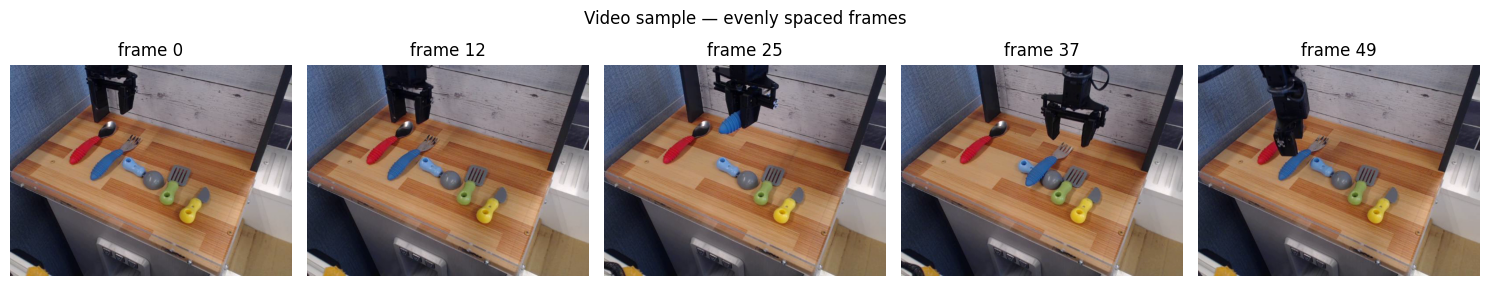

In [ ]:
import matplotlib.pyplot as plt

try:
    import decord
    vr = decord.VideoReader(BytesIO(raw))
    n = len(vr)
    ## Sample 5 frames evenly spaced across the video.
    indices = [0, n // 4, n // 2, 3 * n // 4, n - 1] 
    frames = vr.get_batch(indices).asnumpy()

    fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
    for ax, frame, idx in zip(axes, frames, indices):
        ax.imshow(frame)
        ax.set_title(f'frame {idx}')
        ax.axis('off')
    plt.suptitle('Video sample — evenly spaced frames')
    plt.tight_layout()
    plt.show()
except (ImportError, Exception) as e:
    print(f'Could not display frames: {e}')

In [10]:
# observation_data / policy_data structure
for key in ('observation_data', 'policy_data'):
    val = sample.get(key)
    if val is None:
        continue
    print(f'--- {key} ---')
    if isinstance(val, dict):
        for k, v in val.items():
            shape = np.array(v).shape if not isinstance(v, str) else ''
            print(f'  {k}: type={type(v).__name__}  shape={shape}')
    else:
        print(f'  type={type(val).__name__}  value={val}')

--- observation_data ---
  joint_effort: type=list  shape=(50, 6)
  qpos: type=list  shape=(50, 6)
  qvel: type=list  shape=(50, 6)
  full_state: type=list  shape=(50, 7)
  state: type=list  shape=(50, 7)
  desired_state: type=list  shape=(50, 7)
  time_stamp: type=list  shape=(50,)
  eef_transform: type=list  shape=(50, 4, 4)
  high_bound: type=list  shape=(50, 5)
  low_bound: type=list  shape=(50, 5)
  env_done: type=list  shape=(50,)
  t_get_obs: type=list  shape=(50,)
--- policy_data ---
  type=list  value=[{'actions': [-0.009635097618313555, 0.0020389753417440846, 0.008556558125919024, 0.010056605560978626, -0.02969081868677377, -0.9352776453936927, 0.9999390956835381]}, {'actions': [-0.007332727544076146, -0.004626264141988624, -0.003965322812740666, 0.010517121640705415, -0.04560057767040735, -0.9104933767872954, 1.0]}, {'actions': [-0.005933353000274138, -0.0023430904544242985, 0.006685287639164773, 0.02452966555339212, -0.04452577392193624, -0.7776737371400254, 0.9939047406148

## Image dataset

In [11]:
image_ds = ds['image']
if hasattr(image_ds, 'keys'):
    image_split = image_ds[list(image_ds.keys())[0]]
else:
    image_split = image_ds

img_samples = list(image_split.take(N))
print('columns     :', image_split.column_names)
print('features    :')
for k, v in image_split.features.items():
    print(f'  {k}: {v}')

columns     : ['first_image', 'intermediate_image', 'frame_43_image', 'campaign_name', 'session_name', 'trajectory_name', 'trajectory_index', 'trajectory_id']
features    :
  first_image: Image(mode=None, decode=True)
  intermediate_image: Image(mode=None, decode=True)
  frame_43_image: Image(mode=None, decode=True)
  campaign_name: Value('string')
  session_name: Value('string')
  trajectory_name: Value('string')
  trajectory_index: Value('int64')
  trajectory_id: Value('string')


In [12]:
img_sample = img_samples[0]
print('sample keys:', list(img_sample.keys()))

for key, val in img_sample.items():
    if hasattr(val, 'size'):  # PIL Image
        print(f'{key}: PIL Image  size={val.size}  mode={val.mode}')
    elif hasattr(val, 'shape'):
        print(f'{key}: array  shape={val.shape}  dtype={val.dtype}')
    else:
        print(f'{key}: {type(val).__name__} = {val}')

sample keys: ['first_image', 'intermediate_image', 'frame_43_image', 'campaign_name', 'session_name', 'trajectory_name', 'trajectory_index', 'trajectory_id']
first_image: PIL Image  size=(640, 480)  mode=RGB
intermediate_image: PIL Image  size=(640, 480)  mode=RGB
frame_43_image: PIL Image  size=(640, 480)  mode=RGB
campaign_name: str = pnp_utensils_11-29
session_name: str = 2022-11-29_15-24-23
trajectory_name: str = traj0
trajectory_index: int = 0
trajectory_id: str = traj_0000_pnp_utensils_11-29_2022-11-29_15-24-23_traj0


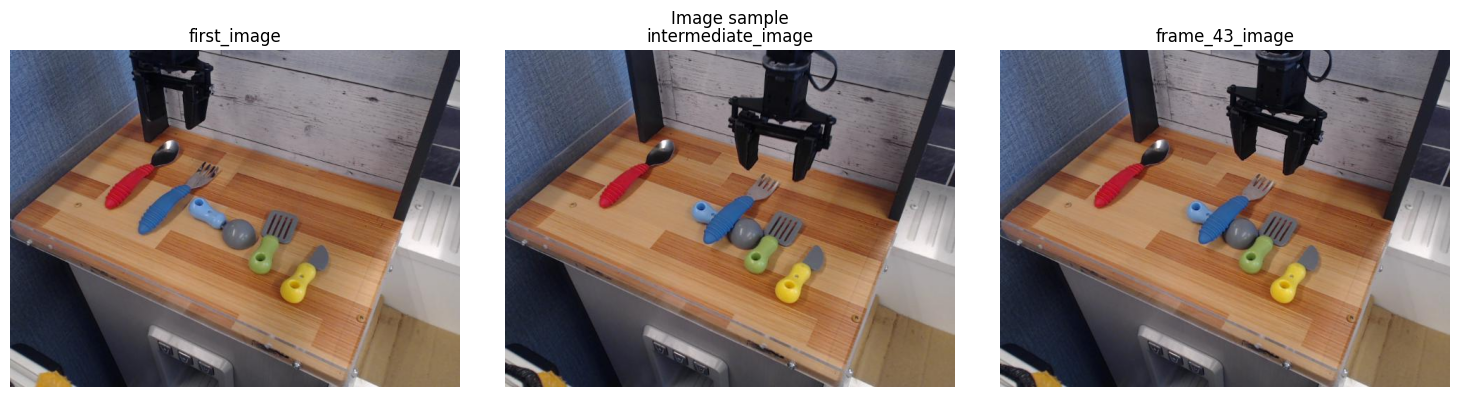

In [13]:
import matplotlib.pyplot as plt

image_keys = [k for k, v in img_sample.items() if hasattr(v, 'size') or hasattr(v, 'shape')]
if image_keys:
    fig, axes = plt.subplots(1, len(image_keys), figsize=(5 * len(image_keys), 4))
    if len(image_keys) == 1:
        axes = [axes]
    for ax, key in zip(axes, image_keys):
        ax.imshow(img_sample[key])
        ax.set_title(key)
        ax.axis('off')
    plt.suptitle('Image sample')
    plt.tight_layout()
    plt.show()
else:
    print('No image columns found in sample')